In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
import os
import subprocess
import gc
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.0.2
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [2]:
vector.register_awkward()

In [15]:
file = uproot.open("/pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root")  # runXXX.mc.root pour les donnees simulees

gen = file["genTree"]
gen.show()

n = gen.arrays(["nMuonsGen","Muon_GenPx","Muon_GenPy","Muon_GenPz","Muon_GenE","zVtxMC","Muon_GenLabel","Muon_GenMotherPDGCode"])
#n[1].show()

#nMuonsGen = 0
#for i in range(len(m)):
 #   info = m[i]["nMuonsGen"]
  #  nMuonsGen += info
#print("nMuonsGen = ", nMuonsGen)

events = file["eventsTree"]
events.show()   #montre toutes les quantitées que l'on peut appeler comme event

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
xVtxMC               | double                   | AsDtype('>f8')
yVtxMC               | double                   | AsDtype('>f8')
zVtxMC               | double                   | AsDtype('>f8')
nMuonsGen            | int32_t                  | AsDtype('>i4')
Muon_GenE            | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPx           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenPz           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
Muon_GenLabel        | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
Muon_GenMotherPDG... | std::vector<int32_t>     | AsJagged(AsDtype('>i4'), he...
name                 | typename                 | interpretation                
-----------

In [16]:
#id = ak.where(n.Muon_GenMotherPDGCode == 100443)  #les muons ne sont générés que par paire
#print(id[0])
#print(type(id[0]))
#print(len(id[0]))

m = events.arrays(
    ["nMuons", "Muon_Px", "Muon_Py", "Muon_Pz", "Muon_Charge", "Muon_E","isCMUL","zVtx","Muon_matchedTrgThreshold","Muon_MCLabel"],
    how="zip")

#nombre de muons reconstruit
#id Jpsi : 443
id_gen = n.Muon_GenLabel
print("identifiant unique de chaque muon généré", id_gen)
id_MC = m.Muon.MCLabel 
print("identifiant unique de chaque muon dans le MC", id_MC)
gen_mask = (ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1)) #filtre pour n'avoir que les J/psi générés
mask = (m["nMuons"] >= 2) & ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1) #permet de ne garder que le Jpsi et filtre les psi(2S)
inverse_mask = ~((m["nMuons"] >= 2) & ak.all(n["Muon_GenMotherPDGCode"] == 443, axis=1))


identifiant unique de chaque muon généré [[1, 2], [1, 2], [1, 2], [1, 2], [1, ...], ..., [1, 2], [1, 2], [1, 2], [1, 2]]
identifiant unique de chaque muon dans le MC [[1, 2], [2, 1], [1], [2, 1], [2], [], ..., [], [1], [1, 2], [2, 1], [1], [2]]


nombre de J/psi générés :  100140
[[3.1], [3.1], [3.1], [2.76], [3.1], ..., [3.1], [3.1], [3.1], [3.1], [3.1]]


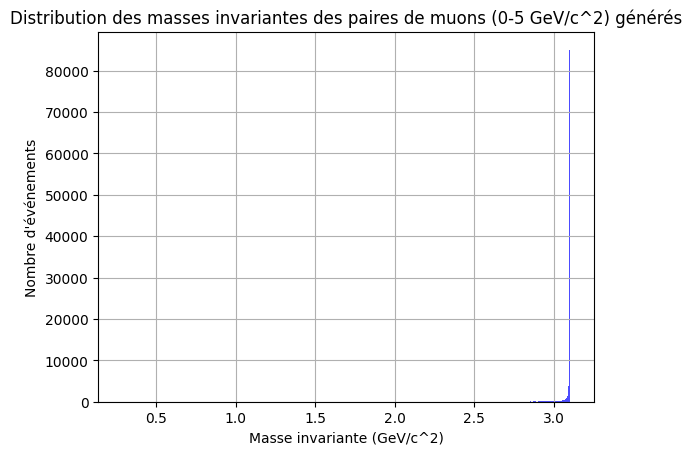

In [34]:
###############################  spectre en masse invariante pour les données générées  ############################### 

filtered_genevents = n[gen_mask] #ici on fait les coupures sur les événements générés. Le mask permet de ne garder que le Jpsi
nb_jpsi_gen = len(filtered_genevents)
print("nombre de J/psi générés : ",nb_jpsi_gen)
# Initialiser les vecteurs à partir des données des muons après coupure
muon_genvectors = ak.zip({
    "px": filtered_genevents.Muon_GenPx,
    "py": filtered_genevents.Muon_GenPy,
    "pz": filtered_genevents.Muon_GenPz,
    "E": filtered_genevents.Muon_GenE
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement après coupure
invariant_genmasses = ak.combinations(muon_genvectors, 2, fields=["muonC", "muonD"])
masses_gen = (invariant_genmasses.muonC + invariant_genmasses.muonD).mass
print(masses_gen)
# Créer un histogramme des valeurs de la masse
flattened_masses_gen = ak.flatten(masses_gen)  # Aplatir les données pour l'histogramme

filtered_masses_gen = flattened_masses_gen[(flattened_masses_gen >= 0) & (flattened_masses_gen <= 5)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_masses_gen, bins=500, color='blue', alpha=0.7)
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2) générés')
plt.grid(True)
plt.show()

nombre d'événement avant coupure :  150000


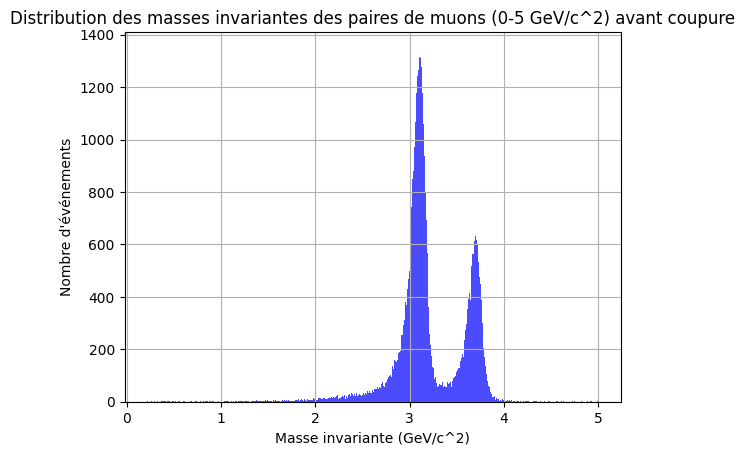

In [19]:
print("nombre d'événement avant coupure : ",len(m))

#print(m[2].to_list())
# Initialiser les vecteurs à partir des données des muons avant coupure
muon_nocut = ak.zip({
    "px": m.Muon.Px,
    "py": m.Muon.Py,
    "pz": m.Muon.Pz,
    "E": m.Muon.E
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement avant coupure
inv_masses_nocut = ak.combinations(muon_nocut, 2, fields=["muonA", "muonB"])
masses_nocut = (inv_masses_nocut.muonA + inv_masses_nocut.muonB).mass

# Créer un histogramme des valeurs de la masse
flattened_masses_nc = ak.flatten(masses_nocut)  # Aplatir les données pour l'histogramme
filtered_masses_nc = flattened_masses_nc[(flattened_masses_nc >= 0) & (flattened_masses_nc <= 5)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_masses_nc, bins=500, color='blue', alpha=0.7)
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2) avant coupure')
plt.grid(True)
plt.show()

nombre de Jpsi reconstruit 22801
[[1.3], [1.6], [3.98], [7.36], [3.23], ..., [2.03], [3.53], [2.49], [0.996]]
<class 'awkward.highlevel.Array'>
<class 'vector.backends.awkward.MomentumArray4D'>
taille de l'histogramme 22803


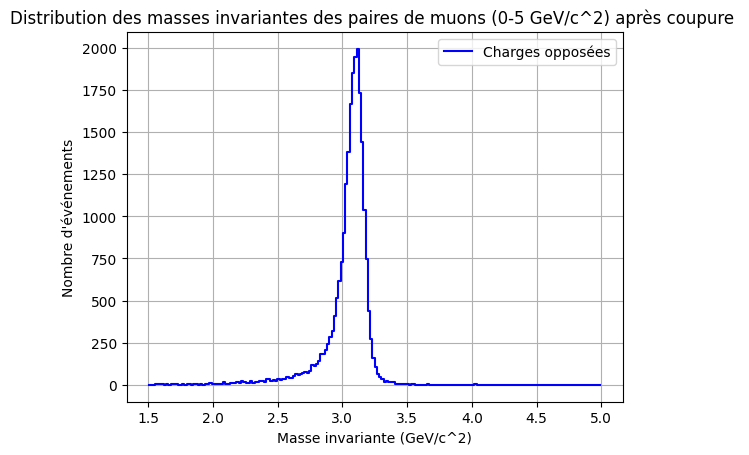

In [41]:
# Filtrer les événements avec nMuons == 2 et isCMUL == True
#attention lors d'une coupure à regarder le nb d'event avant et après pour savoir si on supprime pas trop d'event

filtered_events = m[ (m.isCMUL)&(abs(m.zVtx)<10) & mask] #ici on fait les coupures sur les événements. Le mask permet de ne garder que le Jpsi
#print(ak.where(m.isCMSH == True))
nb_jpsi = len(filtered_events)
print("nombre de Jpsi reconstruit",nb_jpsi)
# Initialiser les vecteurs à partir des données des muons après coupure
muon_vectors = ak.zip({
    "px": filtered_events.Muon.Px,
    "py": filtered_events.Muon.Py,
    "pz": filtered_events.Muon.Pz,
    "E": filtered_events.Muon.E
}, with_name="Momentum4D")

# Calculer les masses invariantes pour chaque paire de muons dans chaque événement après coupure
invariant_masses = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
masses = (invariant_masses.muon1 + invariant_masses.muon2).mass
pT = (invariant_masses.muon1 + invariant_masses.muon2).pt

print(pT)
print(type(invariant_masses))
print(type(muon_vectors))
# Créer un histogramme des valeurs de la masse
flattened_masses = ak.flatten(masses)  # Aplatir les données pour l'histogramme
#print(masses[22798],masses[22799],masses[22800])
#print(masses)
#print(type(masses))
#print(flattened_masses[22800],flattened_masses[22801],flattened_masses[22802])
#print(flattened_masses)
#print(type(flattened_masses))

# Calcul des histogrammes avec numpy
bins = 200
hist, bin_edges = np.histogram(flattened_masses, bins=bins, range=(1.5, 5))
print("taille de l'histogramme",len(flattened_masses))

# Tracer l'histogramme
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, hist, where="mid", label="Charges opposées", color="blue")
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel('Nombre d\'événements')
plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2) après coupure ')
plt.grid(True)
plt.legend()
plt.show()

#filtered_masses = flattened_masses[(flattened_masses >= 0) & (flattened_masses <= 5)]  # Filtrer les masses entre 0 et 10
#plt.hist(filtered_masses, bins=500, color='blue', alpha=0.7)
#plt.xlabel('Masse invariante (GeV/c^2)')
#plt.ylabel("Nombre d'événements")
#plt.title('Distribution des masses invariantes des paires de muons (0-5 GeV/c^2) après coupure')
#plt.grid(True)
#plt.show()

Paramètres CB2 : [3.82252611e+02 3.10255534e+00 6.13916794e-02 7.57256249e-01
 6.37457794e+00]
Paramètres NA60 : [ 1.83730118e+03  3.10107668e+00  8.24862885e-02  1.00000000e-01
  1.00000000e-01 -8.02833969e-03  4.37411660e-01]


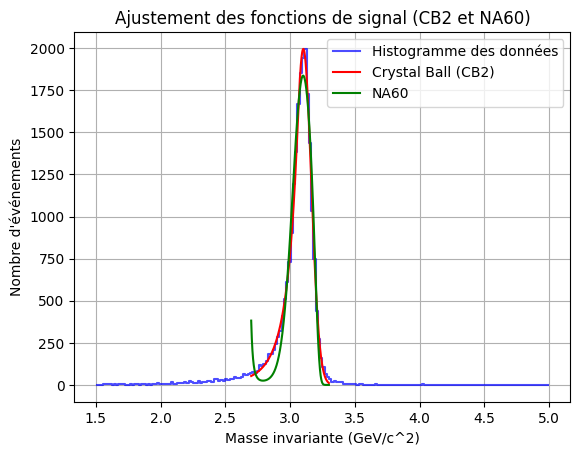

In [27]:
#fit du jpsi
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf  # Import de la fonction d'erreur

#bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_centers = np.asarray((bin_edges[:-1] + bin_edges[1:]) / 2)
y_data = np.asarray(hist)
# Filtrer les données pour la région du pic [2.7, 3.3]
valid_indices = (bin_centers >= 2.7) & (bin_centers <= 3.3)
x_peak = bin_centers[valid_indices]
y_peak = y_data[valid_indices]

# Définir la fonction CB2 (Crystal Ball)
def crystal_ball(x, N, mu, sigma, alpha, n):
    t = (x - mu) / sigma
    A = (n / abs(alpha))**n * np.exp(-alpha**2 / 2)
    B = n / abs(alpha) - abs(alpha)
    C = (n / abs(alpha)) / (n - 1) * np.exp(-alpha**2 / 2)
    D = np.sqrt(np.pi / 2) * (1 + erf(abs(alpha) / np.sqrt(2)))
    norm = sigma * (C + D)
    result = np.piecewise(
        t,
        [t > -alpha, t <= -alpha],
        [lambda t: N * np.exp(-t**2 / 2) / norm,
         lambda t: N * A * (B - t)**(-n) / norm]
    )
    return result

# Définir la fonction NA60
def na60(x, N, mu, sigma, alphaL, alphaR, pL, pR):
    t = (x - mu) / sigma
    t_s = np.piecewise(
        t,
        [t < -alphaL, (t >= -alphaL) & (t <= alphaR), t > alphaR],
        [lambda t: 1 + pL * (-alphaL - t)**3,
         lambda t: 1,
         lambda t: 1 + pR * (t - alphaR)**3]
    )
    return N * np.exp(-0.5 * (t**2) * t_s)

# Ajustement des paramètres pour CB2 et NA60
try:
    popt_cb2, pcov_cb2 = curve_fit(
        crystal_ball, x_peak, y_peak,
        p0=[np.max(y_peak), 3.0, 0.1, 1.5, 5],
        bounds=([0, 2.7, 0.01, 0.1, 1], [np.inf, 3.3, 1, 5, 10]),
        maxfev=200000
    )
except RuntimeError as e:
    print("Erreur d'ajustement Crystal Ball :", e)

try:
    popt_na60, pcov_na60 = curve_fit(
        na60, x_peak, y_peak,
        p0=[np.max(y_peak), 3.0, 0.1, 1.5, 1.5, 0.1, 0.1],
        bounds=([0, 2.7, 0.01, 0.1, 0.1, -1, -1], [np.inf, 3.3, 1, 5, 5, 1, 1]),
        maxfev=200000
    )
except RuntimeError as e:
    print("Erreur d'ajustement NA60 :", e)

# Générer les courbes ajustées
x_fit = np.linspace(2.7, 3.3, 1000)
y_cb2 = crystal_ball(x_fit, *popt_cb2) if 'popt_cb2' in locals() else None
y_na60 = na60(x_fit, *popt_na60) if 'popt_na60' in locals() else None

# Résultats de l'ajustement
if 'popt_cb2' in locals():
    print(f"Paramètres CB2 : {popt_cb2}")
if 'popt_na60' in locals():
    print(f"Paramètres NA60 : {popt_na60}")

# Tracer les données et les ajustements
plt.step(bin_centers, y_data, where='mid', label='Histogramme des données', color='blue', alpha=0.7)
if y_cb2 is not None:
    plt.plot(x_fit, y_cb2, label='Crystal Ball (CB2)', color='red')
if y_na60 is not None:
    plt.plot(x_fit, y_na60, label='NA60', color='green')

# Mise en forme
plt.xlabel('Masse invariante (GeV/c^2)')
plt.ylabel('Nombre d\'événements')
plt.title('Ajustement des fonctions de signal (CB2 et NA60)')
plt.legend()
plt.grid(True)
plt.show()

22801


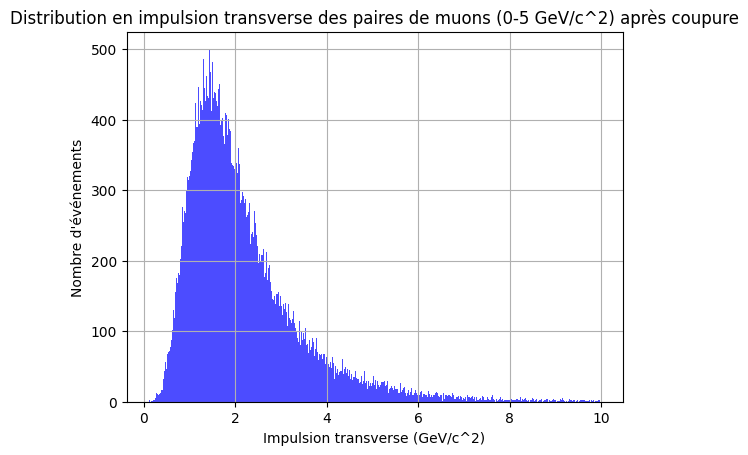

In [22]:
#distribution en pT
pT = muon_vectors.pt
print(len(pT))
flattened_pT = ak.flatten(pT)  # Aplatir les données pour l'histogramme
filtered_pT = flattened_pT[(flattened_pT >= 0) & (flattened_pT <= 10)]  # Filtrer les masses entre 0 et 10
plt.hist(filtered_pT, bins=500, color='blue', alpha=0.7)
plt.xlabel('Impulsion transverse (GeV/c^2)')
plt.ylabel("Nombre d'événements")
plt.title('Distribution en impulsion transverse des paires de muons (0-5 GeV/c^2) après coupure')
plt.grid(True)
plt.show()

In [23]:
acceptance_eff = nb_jpsi / nb_jpsi_gen
print(acceptance_eff)

0.2342239617040073


In [139]:
def getTracks(events):
    return ak.zip({"px":events["Muon_Px"],
                       "py":events["Muon_Py"],
                       "pz":events["Muon_Pz"],
                       "E":events["Muon_E"],
                       "charge":events["Muon_Charge"],
                       "thetaAbs":events["Muon_thetaAbs"],
                       "matched":events["Muon_matchedTrgThreshold"]},
                    with_name='Momentum4D')

In [102]:
tracks = getTracks(m)
print(m)
print(events)
type(tracks[0])
print(len(tracks))
#print(tracks[0])
a= tracks[0][0] #une trace
b =tracks[0][1] #une trace

c = (a+b).M #un événement contenant 2 traces
print(c)

tracks[0].M #donne la masse invariante pour les différentes traces 
#for j in m[m.nMuons > 1]:
  #  for i in range(len(tracks)):
   #     print(tracks[i].M)


FieldNotFoundError: no field 'Muon_Px' in record with 4 fields

In [103]:
ak.where(m.nMuons ==2)

(<Array [0, 1, 3, 12, ..., 149992, 149993, 149996, 149997] type='43501 * int64'>,)

In [99]:
m[0].to_list()

{'nMuons': 2,
 'isCMUL': True,
 'zVtx': -4.777190685272217,
 'isCMSH': True,
 'Muon': [{'Px': 2.0223944187164307,
   'Py': -0.9315006732940674,
   'Pz': -30.101959228515625,
   'Charge': 1,
   'E': 30.18438148498535,
   'matchedTrgThreshold': 2},
  {'Px': -0.7104543447494507,
   'Py': -3.694413423538208,
   'Pz': -66.21504211425781,
   'Charge': -1,
   'E': 66.32191467285156,
   'matchedTrgThreshold': 3}]}

In [ ]:
#compter le nb de Jpsi reconstruit et le nb de Jpsi généré
#puis diviser le nb de Jpsi reconstruit par le nb de Jpsi généré afin d'avoir l'acceptance efficacité
#on obtient l'acceptance efficacité avec des erreurs stat et syst
#tracer l'évolution de l'acceptance efficacité en fonction de la distribution en pT